In [1]:
import os
import numpy as np
import pandas as pd
from sub_tsmd import generate, plot_motif_sets

## Demonstration time series

In [2]:
if not os.path.exists('demonstration'):
    os.mkdir('demonstration')

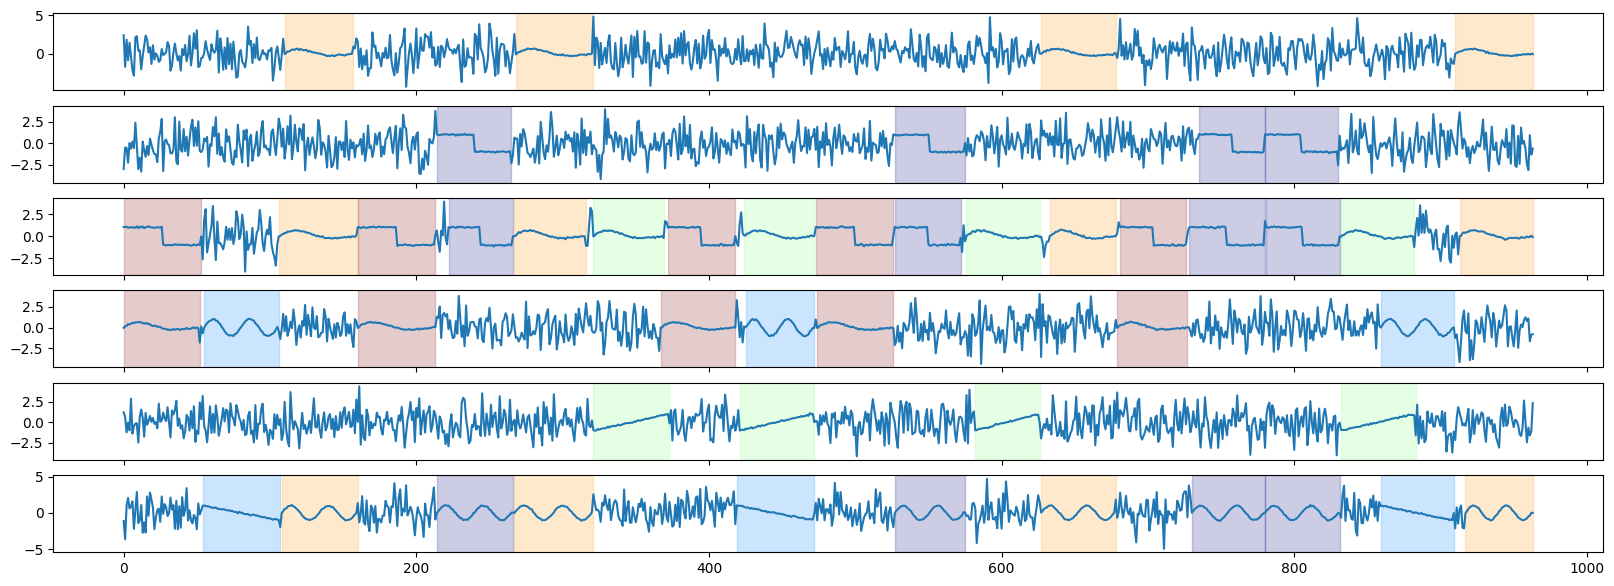

In [3]:
# Subspace 
X, y = generate(
    dimension=6,
    nb_motif_sets=5,
    min_motif_set_size=3,
    max_motif_set_size=5,
    min_motif_dimension=2,
    max_motif_dimension=3,
    univariate_motifs=[
        lambda x: np.sin(np.linspace(0, 2 * np.pi, x)),  # Sinusoidal 
        lambda x: np.concatenate([np.ones(int(np.ceil(x/2))), -1 * np.ones(int(np.floor(x/2)))]),  # Square wave
        lambda x: np.exp(-np.linspace(0, 2, x)) * np.sin(2 * np.pi * np.linspace(0, 1, x)),  # Damped sine
        lambda x: np.cos(np.linspace(0, 2 * np.pi, x)),  # Cosine wave
        lambda x: np.linspace(-1, 1, x),  # Linear increasings
        lambda x: np.sin(4 * np.pi * np.linspace(0, 1, x)),  # Higher frequency sine
        lambda x: np.sign(np.sin(np.linspace(0, 4 * np.pi, x))),  # Square wave-like signal
        lambda x: np.sin(4 * np.pi * np.linspace(0, 1, x)),  # Higher frequency sine
        lambda x: np.linspace(1, -1, x)  # Linear decreasing
    ], 
    min_motif_length=45,
    max_motif_length=55,
    white_space=0, 
    nb_motif_repositions=1,
    noise_general=0.05,
    noise_non_motif=1.5,
    seed=0
)
pd.DataFrame(data={'ts': [X], 'gt': [y]}).to_pickle('demonstration/subspace.pkl')
plot_motif_sets(X, y);

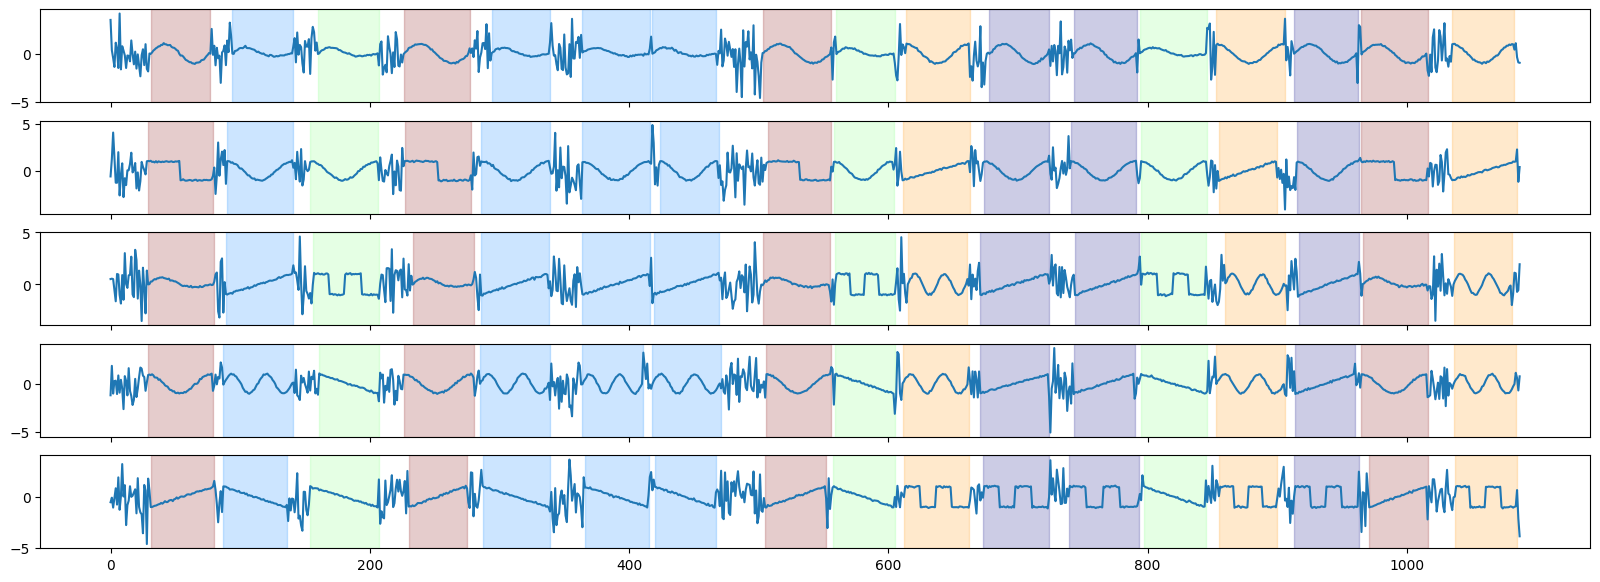

In [4]:
# Full dimensional
X, y = generate(
    dimension=5,
    nb_motif_sets=5,
    min_motif_set_size=3,
    max_motif_set_size=5,
    min_motif_dimension=5,
    max_motif_dimension=5,
    univariate_motifs=[
        lambda x: np.sin(np.linspace(0, 2 * np.pi, x)),  # Sinusoidal 
        lambda x: np.concatenate([np.ones(int(np.ceil(x/2))), -1 * np.ones(int(np.floor(x/2)))]),  # Square wave
        lambda x: np.exp(-np.linspace(0, 2, x)) * np.sin(2 * np.pi * np.linspace(0, 1, x)),  # Damped sine
        lambda x: np.cos(np.linspace(0, 2 * np.pi, x)),  # Cosine wave
        lambda x: np.linspace(-1, 1, x),  # Linear increasings
        lambda x: np.sin(4 * np.pi * np.linspace(0, 1, x)),  # Higher frequency sine
        lambda x: np.sign(np.sin(np.linspace(0, 4 * np.pi, x))),  # Square wave-like signal
        lambda x: np.sin(4 * np.pi * np.linspace(0, 1, x)),  # Higher frequency sine
        lambda x: np.linspace(1, -1, x)  # Linear decreasing
    ], 
    min_motif_length=45,
    max_motif_length=55,
    white_space=200, 
    nb_motif_repositions=0,
    noise_general=0.05,
    noise_non_motif=1.5,
    seed=42
)
pd.DataFrame(data={'ts': [X], 'gt': [y]}).to_pickle('demonstration/full-dimensional.pkl')
plot_motif_sets(X, y);

## Benchmark sets

In [5]:
import scipy

def get_r(X, y, l_min, l_max):
    
    r_max = -1
    length = int(np.round((l_min + l_max) / 2))
    
    for ts, gt in zip(X, y):
        
        for (mask, motif_set) in gt:
            
            instances = np.empty(shape=(motif_set.shape[0], mask.sum(), length))
            for i, motif in enumerate(motif_set):
                c = -1
                for d in range(ts.shape[1]):
                    if not mask[d]:
                        continue
                    c += 1
                    instances[i, c, :] = scipy.signal.resample(ts[motif[0, c]:motif[1, c], d], length)      

            # Compute the distance matrix
            N, D, T = instances.shape
            distance_matrix = scipy.spatial.distance.squareform(scipy.spatial.distance.pdist(instances.reshape(N, D*T), metric='euclidean'))
            
            # Find the R for this class, and update r_max
            r = np.min(np.max(distance_matrix, axis=0))
            if r > r_max:
                r_max = r
    
    return r_max

In [6]:
def generate_benchmark_set(start_seed: int, generation_kwargs: dict):
    columns = {'ds_name': str, 'l_min': int, 'l_max': int, 'D': int, 'k_max' : int, 'r': float, 'n_avg_train': int, 'n_avg_test': int, 'n_avg': int}
    metadata = pd.DataFrame(columns, index=[])
    
    for (name, kwargs) in generation_kwargs.items():
        
        ts, gt = [], []
        
        kwargs = kwargs.copy()
        nb_validation = kwargs.pop('nb_validation')
        nb_test = kwargs.pop('nb_test')
        
        seeds = np.arange(start_seed, start_seed + nb_validation + nb_test)
        for seed in seeds:
            print(f"{name} {seed}/{seeds.max()}")
            X, y = generate(seed=seed, **kwargs)
            ts.append(X)
            gt.append(y)

        # Split in validation & test set
        ts_validation = ts[:nb_validation]
        gt_validation = gt[:nb_validation]
        ts_test = ts[nb_validation:]
        gt_test = gt[nb_validation:]
        
        if not os.path.exists(name.lower()):
            os.mkdir(name.lower())       
            
        pd.DataFrame(data={'ts': ts_validation, 'gt': gt_validation}).to_pickle(f'{name.lower()}/validation.pkl')
        pd.DataFrame(data={'ts': ts_test, 'gt': gt_test}).to_pickle(f'{name.lower()}/test.pkl')

        metadata.loc[len(metadata)] = {
            'ds_name': name.lower(), 
            'D': kwargs['dimension'], 
            'l_min': kwargs['min_motif_length'], 
            'l_max': kwargs['max_motif_length'], 
            'k_max': kwargs['max_motif_set_size'], 
            'N_max': kwargs['nb_motif_sets'],
            'r': get_r(ts_validation, gt_validation, kwargs['min_motif_length'], kwargs['max_motif_length']),
            'n_avg_train': np.mean([i.shape[0] for i in ts_validation]), 
            'n_avg_test': np.mean([i.shape[0] for i in ts_test]), 
            'n_avg': np.mean([i.shape[0] for i in ts])
        }
        
    metadata = metadata.set_index('ds_name')
    metadata.to_csv('metadata.csv')

In [7]:
NB_VALIDATION = 50
NB_TEST = 200
BASE_CONFIGURATION =  {
    'nb_validation': NB_VALIDATION,
    'nb_test': NB_TEST,
    'dimension': 6,
    'nb_motif_sets': 5,
    'min_motif_set_size': 3,
    'max_motif_set_size': 8,
    'min_motif_dimension': 2,
    'max_motif_dimension': 3,
    'univariate_motifs': [
        lambda x: np.sin(np.linspace(0, 2 * np.pi, x)),  # Sinusoidal 
        lambda x: np.concatenate([np.ones(int(np.ceil(x/2))), -1 * np.ones(int(np.floor(x/2)))]),  # Square wave
        lambda x: np.exp(-np.linspace(0, 2, x)) * np.sin(2 * np.pi * np.linspace(0, 1, x)),  # Damped sine
        lambda x: np.cos(np.linspace(0, 2 * np.pi, x)),  # Cosine wave
        lambda x: np.linspace(-1, 1, x),  # Linear increasings
        lambda x: np.sin(4 * np.pi * np.linspace(0, 1, x)),  # Higher frequency sine
        lambda x: np.sign(np.sin(np.linspace(0, 4 * np.pi, x))),  # Square wave-like signal
        lambda x: np.sin(4 * np.pi * np.linspace(0, 1, x)),  # Higher frequency sine
        lambda x: np.linspace(1, -1, x)  # Linear decreasing
    ], 
    'min_motif_length': 50,
    'max_motif_length': 50,
    'nb_motif_repositions': 5,
    'white_space': 0, 
    'noise_general': 0.05,
    'noise_non_motif': 1.0,
}

In [8]:
def extend(d1, d2):
    # Because update changes the dictionary, not the 
    d = d1.copy()
    d.update(d2)
    return d

generate_benchmark_set(start_seed=0, generation_kwargs={
    'simple': extend(BASE_CONFIGURATION, {'nb_validation': 3, 'nb_test': 15}),
    's1': BASE_CONFIGURATION,
    's2': extend(BASE_CONFIGURATION, {'min_motif_length': 45, 'max_motif_length': 55}),
    's3': extend(BASE_CONFIGURATION, {'min_motif_length': 35, 'max_motif_length': 65}),
    's4': extend(BASE_CONFIGURATION, {'dimension': 12, 'min_motif_dimension': 3, 'max_motif_dimension': 6}),
    's5': extend(BASE_CONFIGURATION, {'dimension': 12, 'min_motif_dimension': 3, 'max_motif_dimension': 6, 'min_motif_length': 45, 'max_motif_length': 55}),
    's6': extend(BASE_CONFIGURATION, {'dimension': 12, 'min_motif_dimension': 3, 'max_motif_dimension': 6, 'min_motif_length': 35, 'max_motif_length': 65}),
})

simple 0/17
simple 1/17
simple 2/17
simple 3/17
simple 4/17
simple 5/17
simple 6/17
simple 7/17
simple 8/17
simple 9/17
simple 10/17
simple 11/17
simple 12/17
simple 13/17
simple 14/17
simple 15/17
simple 16/17
simple 17/17
base 0/249
base 1/249
base 2/249
base 3/249
base 4/249
base 5/249
base 6/249
base 7/249
base 8/249
base 9/249
base 10/249
base 11/249
base 12/249
base 13/249
base 14/249
base 15/249
base 16/249
base 17/249
base 18/249
base 19/249
base 20/249
base 21/249
base 22/249
base 23/249
base 24/249
base 25/249
base 26/249
base 27/249
base 28/249
base 29/249
base 30/249
base 31/249
base 32/249
base 33/249
base 34/249
base 35/249
base 36/249
base 37/249
base 38/249
base 39/249
base 40/249
base 41/249
base 42/249
base 43/249
base 44/249
base 45/249
base 46/249
base 47/249
base 48/249
base 49/249
base 50/249
base 51/249
base 52/249
base 53/249
base 54/249
base 55/249
base 56/249
base 57/249
base 58/249
base 59/249
base 60/249
base 61/249
base 62/249
base 63/249
base 64/249
base 6